In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import os

BASE      = '/content/drive/MyDrive/Mental-Health'
DAIC_OLD  = os.path.join(BASE, 'DAIC')
EXT_DAIC  = os.path.join(BASE, 'Extended-DAIC')
EXT_DATA  = os.path.join(EXT_DAIC, 'data')
EXT_LABEL = os.path.join(EXT_DAIC, 'labels')
OUT       = os.path.join(BASE, 'outputs', 'facial')
os.makedirs(OUT, exist_ok=True)

HAS_OLD = os.path.isdir(DAIC_OLD)
HAS_EXT = os.path.isdir(EXT_DATA)
print(f'DAIC-WOZ (old): {"✅" if HAS_OLD else "❌"}'  )
print(f'Extended-DAIC:  {"✅" if HAS_EXT else "❌"}'  )
assert HAS_OLD or HAS_EXT, 'No data directory found! Check BASE path.'

DATA_ROOTS = []
if HAS_EXT: DATA_ROOTS.append(('ext', EXT_DATA))
if HAS_OLD: DATA_ROOTS.append(('old', DAIC_OLD))
print(f'\nData roots to load: {[r[0] for r in DATA_ROOTS]}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DAIC-WOZ (old): ✅
Extended-DAIC:  ✅

Data roots to load: ['ext', 'old']


In [3]:
!pip install -q scikit-learn lightgbm imbalanced-learn torch torchvision joblib shap
import torch
print('GPU:', torch.cuda.is_available(),
      torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')

GPU: False none


## Imports + Config

In [ ]:
import os, json, random, warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, joblib
from scipy.stats import skew, kurtosis
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt, seaborn as sns

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
BINARY_THR = 10
MAX_NAN    = 0.30
SEED       = 42
CLASS_NAMES= ['Not depressed', 'Depressed']
FER_EMO    = ['angry','disgust','fear','happy','neutral','sad','surprise']
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print('Device:', DEVICE)

Device: cpu


## Step 1 — Load Labels from BOTH Datasets


In [ ]:
def load_split_csv(path):
    """Load one of train/dev/test_split.csv from Extended-DAIC labels folder."""
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(' ','_') for c in df.columns]
    phq = next((c for c in df.columns if 'phq8' in c or ('phq' in c and 'score' in c)), None)
    if phq is None: phq = next((c for c in df.columns if 'phq' in c), None)
    pid = next((c for c in df.columns if 'participant' in c or c in ('id','pid','subject')), None)
    if phq is None or pid is None:
        print(f'  Columns: {list(df.columns)}')
        raise ValueError(f'Cannot find PHQ/PID columns in {path}')
    df['label'] = (df[phq].astype(float) >= BINARY_THR).astype(int)
    df = df.rename(columns={pid: 'participant_id', phq: 'phq_score'})
    return df[['participant_id','phq_score','label']].dropna().astype({'participant_id': int})

split_files = {
    'train': os.path.join(EXT_LABEL, 'train_split.csv'),
    'dev':   os.path.join(EXT_LABEL, 'dev_split.csv'),
    'test':  os.path.join(EXT_LABEL, 'test_split.csv'),
}

split_dfs = {}
for name, path in split_files.items():
    if os.path.exists(path):
        split_dfs[name] = load_split_csv(path)
        split_dfs[name]['split'] = name
        print(f'{name}: {len(split_dfs[name])} participants | '
              f'dep={split_dfs[name].label.sum()} | '
              f'non-dep={(split_dfs[name].label==0).sum()}')
    else:
        print(f'WARNING: {path} not found')
if split_dfs:
    labels_all = pd.concat(list(split_dfs.values()), ignore_index=True).drop_duplicates('participant_id')
else:
    labels_all = pd.DataFrame(columns=['participant_id', 'phq_score', 'label', 'split'])
detailed_path = os.path.join(EXT_LABEL, 'Detailed_PHQ8_Labels.csv')
if os.path.exists(detailed_path):
    detailed_labels = load_split_csv(detailed_path)
    detailed_labels['split'] = 'unknown'

    new_detailed_pids = detailed_labels[~detailed_labels.participant_id.isin(labels_all.participant_id)]
    if not new_detailed_pids.empty:
        labels_all = pd.concat([labels_all, new_detailed_pids], ignore_index=True)
        print(f'Merged {len(new_detailed_pids)} new participants from Detailed_PHQ8_Labels.csv')


print(f'\nTotal labels: {len(labels_all)} | dep: {labels_all.label.sum()} | '
      f'non-dep: {(labels_all.label==0).sum()}')

if HAS_OLD:
    old_label_path = os.path.join(DAIC_OLD, 'labels.csv')
    if os.path.exists(old_label_path):
        old_labels = load_split_csv(old_label_path)
        old_labels['split'] = 'unknown'
        old_new = old_labels[~old_labels.participant_id.isin(labels_all.participant_id)]
        if len(old_new):
            labels_all = pd.concat([labels_all, old_new], ignore_index=True)
            print(f'Merged {len(old_new)} extra participants from DAIC-WOZ')

labels_lut = labels_all.set_index('participant_id')

train: 163 participants | dep=50 | non-dep=113
dev: 56 participants | dep=15 | non-dep=41
test: 56 participants | dep=21 | non-dep=35

Total labels: 275 | dep: 86 | non-dep: 189


## Step 2 — Load Pre-extracted OpenFace/CLNF Features


In [13]:
def aggregate_frame_level(df, prefix, skip_cols=None):
    """8-statistic temporal aggregation of frame-level OpenFace features."""
    df = df.replace([999.0, -999.0, -1.0], np.nan)
    if skip_cols:
        fcols = [c for c in df.columns if c not in skip_cols]
    else:
        # Skip metadata columns: frame, timestamp, confidence, success
        fcols = [c for c in df.columns
                 if not any(k in c.lower() for k in ['frame','timestamp','confidence','success'])]
    feat = {}
    for col in fcols:
        v = pd.to_numeric(df[col], errors='coerce').dropna().values
        k = f'{prefix}_{str(col).strip().replace(" ","_").replace(".","_").replace("/","_")}'
        if len(v) < 2:
            for s in ['mn','sd','mx','md','iq','sk','ku','vr']: feat[f'{k}_{s}'] = np.nan
            continue
        feat[f'{k}_mn'] = float(np.mean(v))
        feat[f'{k}_sd'] = float(np.std(v))
        feat[f'{k}_mx'] = float(np.max(v))
        feat[f'{k}_md'] = float(np.median(v))
        feat[f'{k}_iq'] = float(np.percentile(v,75) - np.percentile(v,25))
        feat[f'{k}_sk'] = float(skew(v)) if len(v) > 3 else 0.0
        feat[f'{k}_ku'] = float(kurtosis(v)) if len(v) > 3 else 0.0
        feat[f'{k}_vr'] = float(np.max(np.abs(v)) / (np.mean(np.abs(v)) + 1e-6))  # variability ratio
    return feat


def load_bovw_features(path):
    """Load Bag-of-Visual-Words features (already aggregated, 1 row per participant)."""
    try:
        df = pd.read_csv(path, header=None)
        # BoVW CSVs are single-row histograms — return as flat dict
        return {f'bovw_{i}': float(v) for i, v in enumerate(df.values.flatten())}
    except:
        return {}


def load_participant_facial(pdir, pid):
    """Load all available facial features for one Extended-DAIC participant."""
    feat_dir = os.path.join(pdir, 'features')
    feat = {}
    any_loaded = False

    # ── Frame-level OpenFace (AU + Pose + Gaze) ────────────────────────────
    of_path = os.path.join(feat_dir, f'{pid}_OpenFace2.1.0_Pose_gaze_AUs.csv')
    if os.path.exists(of_path):
        try:
            df_of = pd.read_csv(of_path)
            df_of.columns = [c.strip() for c in df_of.columns]
            feat.update(aggregate_frame_level(df_of, 'of'))
            any_loaded = True
        except Exception as e:
            pass

    # ── BoVW features (aggregated) ─────────────────────────────────────────
    bovw_path = os.path.join(feat_dir, f'{pid}_BoVW_openFace_2.1.0_Pose_Gaze_AUs.csv')
    if os.path.exists(bovw_path):
        bovw = load_bovw_features(bovw_path)
        if bovw:
            feat.update(bovw)
            any_loaded = True

    # ── Fallback: try old CLNF format (original DAIC-WOZ) ─────────────────
    if not any_loaded:
        for fname, pfx in [
            (f'{pid}_CLNF_AUs.txt',  'au'),
            (f'{pid}_CLNF_pose.txt', 'pose'),
            (f'{pid}_CLNF_gaze.txt', 'gaze'),
        ]:
            fpath = os.path.join(pdir, fname)
            if not os.path.exists(fpath): continue
            for sep in [',','\t']:
                try:
                    df_clnf = pd.read_csv(fpath, sep=sep, skipinitialspace=True)
                    df_clnf.columns = [c.strip() for c in df_clnf.columns]
                    if df_clnf.shape[1] > 2:
                        feat.update(aggregate_frame_level(df_clnf, pfx))
                        any_loaded = True
                        break
                except:
                    pass

    return feat if any_loaded else None


def load_all_facial_features(data_roots, labels_lut):
    """
    Load facial features from BOTH Extended-DAIC and DAIC-WOZ.
    data_roots: list of (source_tag, data_root_path) tuples.
    Deduplicates by participant_id — first source wins.
    """
    seen_pids = set()
    records   = []
    stats     = {'loaded': 0, 'no_label': 0, 'no_features': 0}

    for source, data_root in data_roots:
        if not os.path.isdir(data_root):
            print(f'  Skipping {source}: directory not found')
            continue

        dirs = sorted([d for d in os.listdir(data_root)
                       if os.path.isdir(os.path.join(data_root, d)) and d.endswith('_P')])
        print(f'\n{source.upper()} — {len(dirs)} participant folders: {data_root}')

        for folder in tqdm(dirs, desc=f'Facial [{source}]'):
            try: pid = int(folder.split('_')[0])
            except: continue

            if pid in seen_pids:       continue   # already loaded from another source
            if pid not in labels_lut.index:
                stats['no_label'] += 1
                continue

            pdir = os.path.join(data_root, folder)
            feat = load_participant_facial(pdir, pid)
            if feat is None:
                stats['no_features'] += 1
                continue

            row = labels_lut.loc[pid]
            feat['participant_id'] = pid
            feat['label']          = int(row['label'])
            feat['phq_score']      = float(row['phq_score'])
            feat['split']          = 'train' if source == 'old' else str(row.get('split', 'unknown'))
            feat['source']         = source
            records.append(feat)
            seen_pids.add(pid)
            stats['loaded'] += 1

    print(f'\n=== COMBINED FACIAL LOAD ==='  )
    print(f'Loaded      : {stats["loaded"]} participants')
    print(f'No label    : {stats["no_label"]}')
    print(f'No features : {stats["no_features"]}')

    df = pd.DataFrame(records)
    print(f'Raw feature matrix: {df.shape}')

    meta  = ['participant_id', 'label', 'phq_score', 'split', 'source']
    fcols = [c for c in df.columns if c not in meta]

    # Drop columns with too many NaNs
    nan_frac = df[fcols].isna().mean()
    keep     = nan_frac[nan_frac <= MAX_NAN].index.tolist()
    print(f'Dropped {len(fcols)-len(keep)} high-NaN features → keeping {len(keep)}')

    df = df[meta + keep]
    df[keep] = df[keep].fillna(df[keep].median())
    print(f'Final feature matrix: {df.shape}')
    return df, keep


# ── Load from BOTH datasets ──────────────────────────────────────────────
facial_df, feat_cols = load_all_facial_features(DATA_ROOTS, labels_lut)

print(f'\nFinal dataset : {len(facial_df)} participants')
print(f'Depressed     : {facial_df.label.sum()}')
print(f'Not depressed : {(facial_df.label==0).sum()}')
src_counts = facial_df["source"].value_counts().to_dict()
print(f'Source breakdown: {src_counts}')
facial_df.to_csv(os.path.join(OUT, 'facial_features_combined.csv'), index=False)



EXT — 275 participant folders: /content/drive/MyDrive/Mental-Health/Extended-DAIC/data


Facial [ext]:   0%|          | 0/275 [00:00<?, ?it/s]


OLD — 189 participant folders: /content/drive/MyDrive/Mental-Health/DAIC


Facial [old]:   0%|          | 0/189 [00:00<?, ?it/s]


=== COMBINED FACIAL LOAD ===
Loaded      : 275 participants
No label    : 0
No features : 0
Raw feature matrix: (275, 397)
Dropped 0 high-NaN features → keeping 392
Final feature matrix: (275, 397)

Final dataset : 275 participants
Depressed     : 86
Not depressed : 189
Source breakdown: {'ext': 275}


## Step 3 — Emotion Approximation from AUs (Ekman mapping)

In [14]:
def au_to_fer_approx(row):
    """Map AU mean statistics to approximate 7-class emotion distribution (Ekman)."""
    def get(name):
        # Accept both 'au01' and 'AU01' naming conventions
        cols = [c for c in row.index
                if name.lower() in c.lower().replace('_r','').replace('_c','') and '_mn' in c.lower()]
        return float(row[cols[0]]) if cols else 0.0

    au1  = max(0, get('au01'))  # inner brow raise
    au2  = max(0, get('au02'))  # outer brow raise
    au4  = max(0, get('au04'))  # brow lowerer
    au5  = max(0, get('au05'))  # upper lid raiser
    au6  = max(0, get('au06'))  # cheek raiser
    au7  = max(0, get('au07'))  # lid tightener
    au9  = max(0, get('au09'))  # AU09 nose wrinkle - ADDED THIS LINE
    au12 = max(0, get('au12'))  # lip corner puller
    au15 = max(0, get('au15'))  # lip corner depressor
    au17 = max(0, get('au17'))  # chin raiser
    au20 = max(0, get('au20'))  # lip stretcher (fear)
    au23 = max(0, get('au23'))  # lip tightener
    au24 = max(0, get('au24'))  # lip pressor
    au25 = max(0, get('au25'))  # lips part
    au26 = max(0, get('au26'))  # jaw drop

    happy   = au6 * 0.5 + au12 * 0.5
    sad     = au1 * 0.3 + au15 * 0.4 + au17 * 0.3
    angry   = au4 * 0.4 + au23 * 0.3 + au24 * 0.2 + au7 * 0.1
    fear    = au1 * 0.2 + au2 * 0.2 + au5 * 0.2 + au20 * 0.3 + au26 * 0.1
    disgust = au9
    surprise= au1 * 0.2 + au2 * 0.2 + au5 * 0.2 + au26 * 0.4
    neutral = max(0, 1.0 - happy - sad - angry - fear - surprise)
    total   = happy + sad + angry + fear + disgust + surprise + neutral + 1e-9
    return [
        angry/total, disgust/total, fear/total,
        happy/total, neutral/total, sad/total, surprise/total
    ]

meta = ['participant_id','label','phq_score','split']
emo_features = []
for _, row in facial_df.iterrows():
    probs = au_to_fer_approx(row)
    emo   = {f'emo_{FER_EMO[i]}': probs[i] for i in range(7)}
    emo['participant_id'] = row['participant_id']
    emo_features.append(emo)

emo_df = pd.DataFrame(emo_features)
print('Emotion features:', emo_df.shape)
print(emo_df[['emo_happy','emo_sad','emo_neutral','emo_angry']].describe().round(3))

Emotion features: (275, 8)
       emo_happy  emo_sad  emo_neutral  emo_angry
count    275.000  275.000      275.000    275.000
mean       0.297    0.184        0.004      0.192
std        0.142    0.050        0.024      0.103
min        0.009    0.074        0.000      0.040
25%        0.182    0.150        0.000      0.112
50%        0.298    0.181        0.000      0.164
75%        0.395    0.210        0.000      0.255
max        0.661    0.327        0.258      0.543


## Step 4 — Combine Features, VarianceThreshold, Official Splits

In [ ]:
combined = facial_df.merge(emo_df, on='participant_id')
meta = ['participant_id','label','phq_score','split', 'source']
all_feat_cols = [c for c in combined.columns if c not in meta]

X_raw = combined[all_feat_cols].values.astype(np.float32)
y_all = combined['label'].values
pids  = combined['participant_id'].values
vt = VarianceThreshold(threshold=0.001)
X_raw = vt.fit_transform(X_raw)
sel_cols = [all_feat_cols[i] for i in range(len(all_feat_cols)) if vt.get_support()[i]]
print(f'After variance filter: {X_raw.shape[1]} features')

if len(split_dfs) == 3:
    print('Using Extended-DAIC official train/dev/test splits')
    train_pids = set(split_dfs['train'].participant_id)
    dev_pids   = set(split_dfs['dev'].participant_id)
    test_pids  = set(split_dfs['test'].participant_id)

    tr_mask = np.array([p in train_pids for p in pids])
    va_mask = np.array([p in dev_pids   for p in pids])
    te_mask = np.array([p in test_pids  for p in pids])

    unassigned = ~(tr_mask | va_mask | te_mask)
    tr_mask |= unassigned

    tr_idx = np.where(tr_mask)[0]
    va_idx = np.where(va_mask)[0]
    te_idx = np.where(te_mask)[0]
else:
    print('Official splits not found — using random stratified split')
    all_idx = np.arange(len(y_all))
    tv_idx, te_idx = train_test_split(all_idx, test_size=0.15, stratify=y_all, random_state=SEED)
    tr_idx, va_idx = train_test_split(tv_idx, test_size=0.15/0.85, stratify=y_all[tv_idx], random_state=SEED)

print(f'Train: {len(tr_idx)} | Val: {len(va_idx)} | Test: {len(te_idx)}')
print(f'Train dep ratio: {y_all[tr_idx].mean():.2f}')
print(f'Val dep ratio:   {y_all[va_idx].mean():.2f}')
print(f'Test dep ratio:  {y_all[te_idx].mean():.2f}')

scaler   = StandardScaler()
X_tr_raw = scaler.fit_transform(X_raw[tr_idx]);  y_tr = y_all[tr_idx]
X_va_raw = scaler.transform(X_raw[va_idx]);      y_va = y_all[va_idx]
X_te_raw = scaler.transform(X_raw[te_idx]);      y_te = y_all[te_idx]

pca    = PCA(n_components=0.95, random_state=SEED)
X_tr_p = pca.fit_transform(X_tr_raw)
X_va_p = pca.transform(X_va_raw)
X_te_p = pca.transform(X_te_raw)
print(f'PCA: {pca.n_components_} components (95% variance)')
print(f'X_tr: {X_tr_p.shape} | X_va: {X_va_p.shape} | X_te: {X_te_p.shape}')

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
sw = np.array([cw[l] for l in y_tr])
print(f'Class weights: {cw.round(3)}')


After variance filter: 357 features
Using Extended-DAIC official train/dev/test splits
Train: 163 | Val: 56 | Test: 56
Train dep ratio: 0.31
Val dep ratio:   0.27
Test dep ratio:  0.38
PCA: 77 components (95% variance)
X_tr: (163, 77) | X_va: (56, 77) | X_te: (56, 77)
Class weights: [0.721 1.63 ]


## Step 5 — SMOTE Oversampling (on training set only)

In [ ]:
k_neighbors = min(5, int(np.bincount(y_tr).min()) - 1)
k_neighbors = max(1, k_neighbors)
print(f'SMOTE k_neighbors={k_neighbors}')

if k_neighbors >= 1 and np.bincount(y_tr).min() > 1:
    sm = SMOTE(k_neighbors=k_neighbors, random_state=SEED)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr_p, y_tr)
    print(f'After SMOTE: {X_tr_sm.shape} | dep: {y_tr_sm.sum()} | non-dep: {(y_tr_sm==0).sum()}')
else:
    print('Not enough samples for SMOTE — using original training set')
    X_tr_sm, y_tr_sm = X_tr_p, y_tr

cw_sm = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr_sm)
sw_sm = np.array([cw_sm[l] for l in y_tr_sm])

SMOTE k_neighbors=5
After SMOTE: (226, 77) | dep: 113 | non-dep: 113


## Step 6 — RandomForest

In [17]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=10,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)
rf.fit(X_tr_sm, y_tr_sm, sample_weight=sw_sm)
rf_va_prob = rf.predict_proba(X_va_p)[:,1]
rf_te_prob = rf.predict_proba(X_te_p)[:,1]
print(f'RF Val AUC={roc_auc_score(y_va, rf_va_prob):.4f}')
print(f'RF Test AUC={roc_auc_score(y_te, rf_te_prob):.4f}')

RF Val AUC=0.6423
RF Test AUC=0.7279


## Step 7 — LightGBM

In [18]:
n0, n1 = np.bincount(y_tr_sm)
lgbm = lgb.LGBMClassifier(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.02,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_samples=5,
    scale_pos_weight=n0/max(n1,1),
    random_state=SEED,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(
    X_tr_sm, y_tr_sm,
    sample_weight=sw_sm,
    eval_set=[(X_va_p, y_va)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)
lgbm_va_prob = lgbm.predict_proba(X_va_p)[:,1]
lgbm_te_prob = lgbm.predict_proba(X_te_p)[:,1]
print(f'LGB best iter: {lgbm.best_iteration_}')
print(f'LGB Val AUC={roc_auc_score(y_va, lgbm_va_prob):.4f}')
print(f'LGB Test AUC={roc_auc_score(y_te, lgbm_te_prob):.4f}')

LGB best iter: 21
LGB Val AUC=0.4764
LGB Test AUC=0.5714


## Step 8 — MLP (4-layer with residual + label smoothing)

In [ ]:
class FacialDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class FacialMLP(nn.Module):
    """4-layer MLP with residual connections for depression detection."""
    def __init__(self, inp):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Linear(inp, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.4)
        )
        self.resA_main = nn.Sequential(
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(256, 256), nn.BatchNorm1d(256)
        )
        self.bottleneck = nn.Sequential(
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(0.3),
            nn.Linear(128, 128)
        )
        self.head = nn.Linear(128, 2)
        self.act  = nn.GELU()

    def forward(self, x):
        h = self.stem(x)
        h = self.act(h + self.resA_main(h))
        return self.head(self.bottleneck(h))

    def embed(self, x):
        """128-dim embedding for fusion model."""
        with torch.no_grad():
            h = self.stem(x)
            h = self.act(h + self.resA_main(h))
            return self.bottleneck(h)


class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_cls = logits.size(-1)
        log_p = nn.functional.log_softmax(logits, dim=-1)
        smooth_targets = torch.full_like(log_p, self.smoothing / (n_cls - 1))
        smooth_targets.scatter_(-1, targets.unsqueeze(-1), 1.0 - self.smoothing)
        loss = -(smooth_targets * log_p).sum(-1)
        if self.weight is not None:
            loss = loss * self.weight[targets]
        return loss.mean()

counts_sm = np.bincount(y_tr_sm)
ws_sm     = torch.tensor([1.0/counts_sm[l] for l in y_tr_sm], dtype=torch.float32)
sampler   = WeightedRandomSampler(ws_sm, len(ws_sm), replacement=True)

tr_ld = DataLoader(FacialDataset(X_tr_sm, y_tr_sm), batch_size=24, sampler=sampler)
va_ld = DataLoader(FacialDataset(X_va_p, y_va),     batch_size=24)
te_ld = DataLoader(FacialDataset(X_te_p, y_te),     batch_size=24)

mlp      = FacialMLP(X_tr_sm.shape[1]).to(DEVICE)
cw_tensor= torch.tensor(cw_sm, dtype=torch.float32).to(DEVICE)
crit_mlp = LabelSmoothingCE(smoothing=0.1, weight=cw_tensor)
opt_mlp  = optim.AdamW(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
sch_mlp  = optim.lr_scheduler.CosineAnnealingLR(opt_mlp, T_max=80)

best_f1, best_path = -1.0, os.path.join(OUT,'facial_mlp.pt')
hist_f1, hist_auc = [], []

for ep in range(80):
    mlp.train()
    for xb, yb in tr_ld:
        opt_mlp.zero_grad()
        loss = crit_mlp(mlp(xb.to(DEVICE)), yb.to(DEVICE))
        loss.backward()
        nn.utils.clip_grad_norm_(mlp.parameters(), 1.0)
        opt_mlp.step()
    sch_mlp.step()

    mlp.eval(); vp, vprob = [], []
    with torch.no_grad():
        for xb, _ in va_ld:
            logits = mlp(xb.to(DEVICE))
            vp.extend(logits.argmax(-1).cpu().numpy())
            vprob.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())

    vf1  = f1_score(y_va, vp, average='weighted', zero_division=0)
    vauc = roc_auc_score(y_va, vprob)
    hist_f1.append(vf1); hist_auc.append(vauc)

    if vf1 > best_f1:
        best_f1 = vf1; torch.save(mlp.state_dict(), best_path)

    if (ep+1) % 20 == 0:
        print(f'MLP ep{ep+1:>3}: val_F1={vf1:.4f} val_AUC={vauc:.4f} (best={best_f1:.4f})')

mlp.load_state_dict(torch.load(best_path, map_location=DEVICE))
mlp.eval(); mlp_pred_list, mlp_prob_list = [], []
with torch.no_grad():
    for xb, _ in te_ld:
        logits = mlp(xb.to(DEVICE))
        mlp_pred_list.extend(logits.argmax(-1).cpu().numpy())
        mlp_prob_list.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())

mlp_pred = np.array(mlp_pred_list)
mlp_prob = np.array(mlp_prob_list)
print(f'MLP Test F1={f1_score(y_te,mlp_pred,average="weighted",zero_division=0):.4f}  '
      f'AUC={roc_auc_score(y_te,mlp_prob):.4f}')

MLP ep 20: val_F1=0.6071 val_AUC=0.5545 (best=0.6479)
MLP ep 40: val_F1=0.6108 val_AUC=0.5675 (best=0.6496)
MLP ep 60: val_F1=0.6344 val_AUC=0.5902 (best=0.6569)
MLP ep 80: val_F1=0.6344 val_AUC=0.5870 (best=0.6569)
MLP Test F1=0.5833  AUC=0.6422


## Step 9 — Optimal Threshold Search (per-model, on validation set)

In [ ]:
def best_threshold(y_true, y_prob, metric='macro'):
    thrs = np.arange(0.05, 0.96, 0.01)
    scores = [
        f1_score(y_true, (y_prob >= t).astype(int), average=metric, zero_division=0)
        for t in thrs
    ]
    best_t = float(thrs[np.argmax(scores)])
    return best_t, float(max(scores))

rf_thr,   rf_vf1   = best_threshold(y_va, rf_va_prob)
lgbm_thr, lgbm_vf1 = best_threshold(y_va, lgbm_va_prob)

mlp.eval(); mlp_va_prob = []
with torch.no_grad():
    for xb, _ in va_ld:
        logits = mlp(xb.to(DEVICE))
        mlp_va_prob.extend(torch.softmax(logits,-1)[:,1].cpu().numpy())
mlp_va_prob = np.array(mlp_va_prob)
mlp_thr, mlp_vf1 = best_threshold(y_va, mlp_va_prob)

print(f'RF   threshold={rf_thr:.2f}  val_F1={rf_vf1:.4f}')
print(f'LGB  threshold={lgbm_thr:.2f}  val_F1={lgbm_vf1:.4f}')
print(f'MLP  threshold={mlp_thr:.2f}  val_F1={mlp_vf1:.4f}')

rf_pred   = (rf_te_prob   >= rf_thr).astype(int)
lgbm_pred = (lgbm_te_prob >= lgbm_thr).astype(int)
mlp_pred  = (mlp_prob     >= mlp_thr).astype(int)

RF   threshold=0.38  val_F1=0.6151
LGB  threshold=0.46  val_F1=0.5447
MLP  threshold=0.34  val_F1=0.5919


## Step 10 — Weighted Ensemble + Threshold Search

In [ ]:
best_ens_f1, best_w = -1, (1/3, 1/3, 1/3)

for w_rf in np.arange(0.1, 0.7, 0.1):
    for w_lgb in np.arange(0.1, 0.7, 0.1):
        w_mlp = 1.0 - w_rf - w_lgb
        if w_mlp <= 0: continue
        va_ens = w_rf * rf_va_prob + w_lgb * lgbm_va_prob + w_mlp * mlp_va_prob
        thr, f1v = best_threshold(y_va, va_ens)
        if f1v > best_ens_f1:
            best_ens_f1 = f1v
            best_w      = (w_rf, w_lgb, w_mlp)
            best_ens_thr= thr

W_RF, W_LGB, W_MLP = best_w
print(f'Best weights: RF={W_RF:.2f} LGB={W_LGB:.2f} MLP={W_MLP:.2f}')
print(f'Ensemble val F1={best_ens_f1:.4f}  threshold={best_ens_thr:.2f}')

ens_prob = W_RF * rf_te_prob + W_LGB * lgbm_te_prob + W_MLP * mlp_prob
ens_pred = (ens_prob >= best_ens_thr).astype(int)

Best weights: RF=0.40 LGB=0.50 MLP=0.10
Ensemble val F1=0.6358  threshold=0.44


## Step 11 — Evaluate All Models on Test Set

In [22]:
metrics_all = {}
for name, pred, prob in [
    ('RF',        rf_pred,   rf_te_prob),
    ('LightGBM',  lgbm_pred, lgbm_te_prob),
    ('MLP',       mlp_pred,  mlp_prob),
    ('Ensemble',  ens_pred,  ens_prob),
]:
    m = {
        'accuracy': float(accuracy_score(y_te, pred)),
        'f1':       float(f1_score(y_te, pred, average='weighted', zero_division=0)),
        'f1_macro': float(f1_score(y_te, pred, average='macro', zero_division=0)),
        'f1_pos':   float(f1_score(y_te, pred, pos_label=1, average='binary', zero_division=0)),
        'roc_auc':  float(roc_auc_score(y_te, prob)),
    }
    metrics_all[name] = m

print(f'{"Model":<12} {"Acc":>8} {"F1-w":>8} {"F1-mac":>8} {"F1-pos":>8} {"AUC":>8}')
print('-'*60)
for n, m in metrics_all.items():
    print(f'{n:<12} {m["accuracy"]:>8.4f} {m["f1"]:>8.4f} {m["f1_macro"]:>8.4f} '
          f'{m["f1_pos"]:>8.4f} {m["roc_auc"]:>8.4f}')

best_name = max(metrics_all, key=lambda k: metrics_all[k]['f1'])
print(f'\n🏆 Best: {best_name}')
print(classification_report(y_te, ens_pred, target_names=CLASS_NAMES, zero_division=0))

with open(os.path.join(OUT,'facial_metrics.json'),'w') as f:
    json.dump({'facial': metrics_all[best_name], 'all': metrics_all}, f, indent=2)

Model             Acc     F1-w   F1-mac   F1-pos      AUC
------------------------------------------------------------
RF             0.6786   0.6828   0.6680   0.6087   0.7279
LightGBM       0.5536   0.5601   0.5417   0.4681   0.5714
MLP            0.6964   0.6723   0.6348   0.4848   0.6422
Ensemble       0.7143   0.7070   0.6814   0.5789   0.6721

🏆 Best: Ensemble
               precision    recall  f1-score   support

Not depressed       0.74      0.83      0.78        35
    Depressed       0.65      0.52      0.58        21

     accuracy                           0.71        56
    macro avg       0.70      0.68      0.68        56
 weighted avg       0.71      0.71      0.71        56



## Step 12 — 5-Fold Cross-Validation (ground truth metric)

In [ ]:
print('5-fold CV on full dataset (LightGBM)...')
X_all_scaled = scaler.transform(X_raw)
X_all_pca    = pca.transform(X_all_scaled)

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_lgbm = lgb.LGBMClassifier(
    n_estimators=lgbm.best_iteration_ if hasattr(lgbm,'best_iteration_') else 500,
    max_depth=6, learning_rate=0.02, num_leaves=31,
    scale_pos_weight=n0/max(n1,1), random_state=SEED, n_jobs=-1, verbose=-1
)

cv_probs = cross_val_predict(cv_lgbm, X_all_pca, y_all, cv=kf, method='predict_proba')[:,1]
cv_preds = cross_val_predict(cv_lgbm, X_all_pca, y_all, cv=kf)

cv_acc  = float(accuracy_score(y_all, cv_preds))
cv_mf1  = float(f1_score(y_all, cv_preds, average='macro', zero_division=0))
cv_wf1  = float(f1_score(y_all, cv_preds, average='weighted', zero_division=0))
cv_auc  = float(roc_auc_score(y_all, cv_probs))

print(f'\n5-Fold CV (LightGBM on all {len(y_all)} participants)')
print(f'  Accuracy   = {cv_acc:.4f}')
print(f'  F1-macro   = {cv_mf1:.4f}')
print(f'  F1-weighted= {cv_wf1:.4f}')
print(f'  ROC-AUC    = {cv_auc:.4f}')

5-fold CV on full dataset (LightGBM)...

5-Fold CV (LightGBM on all 275 participants)
  Accuracy   = 0.6836
  F1-macro   = 0.4060
  F1-weighted= 0.5581
  ROC-AUC    = 0.4302


## Step 13 — Plots

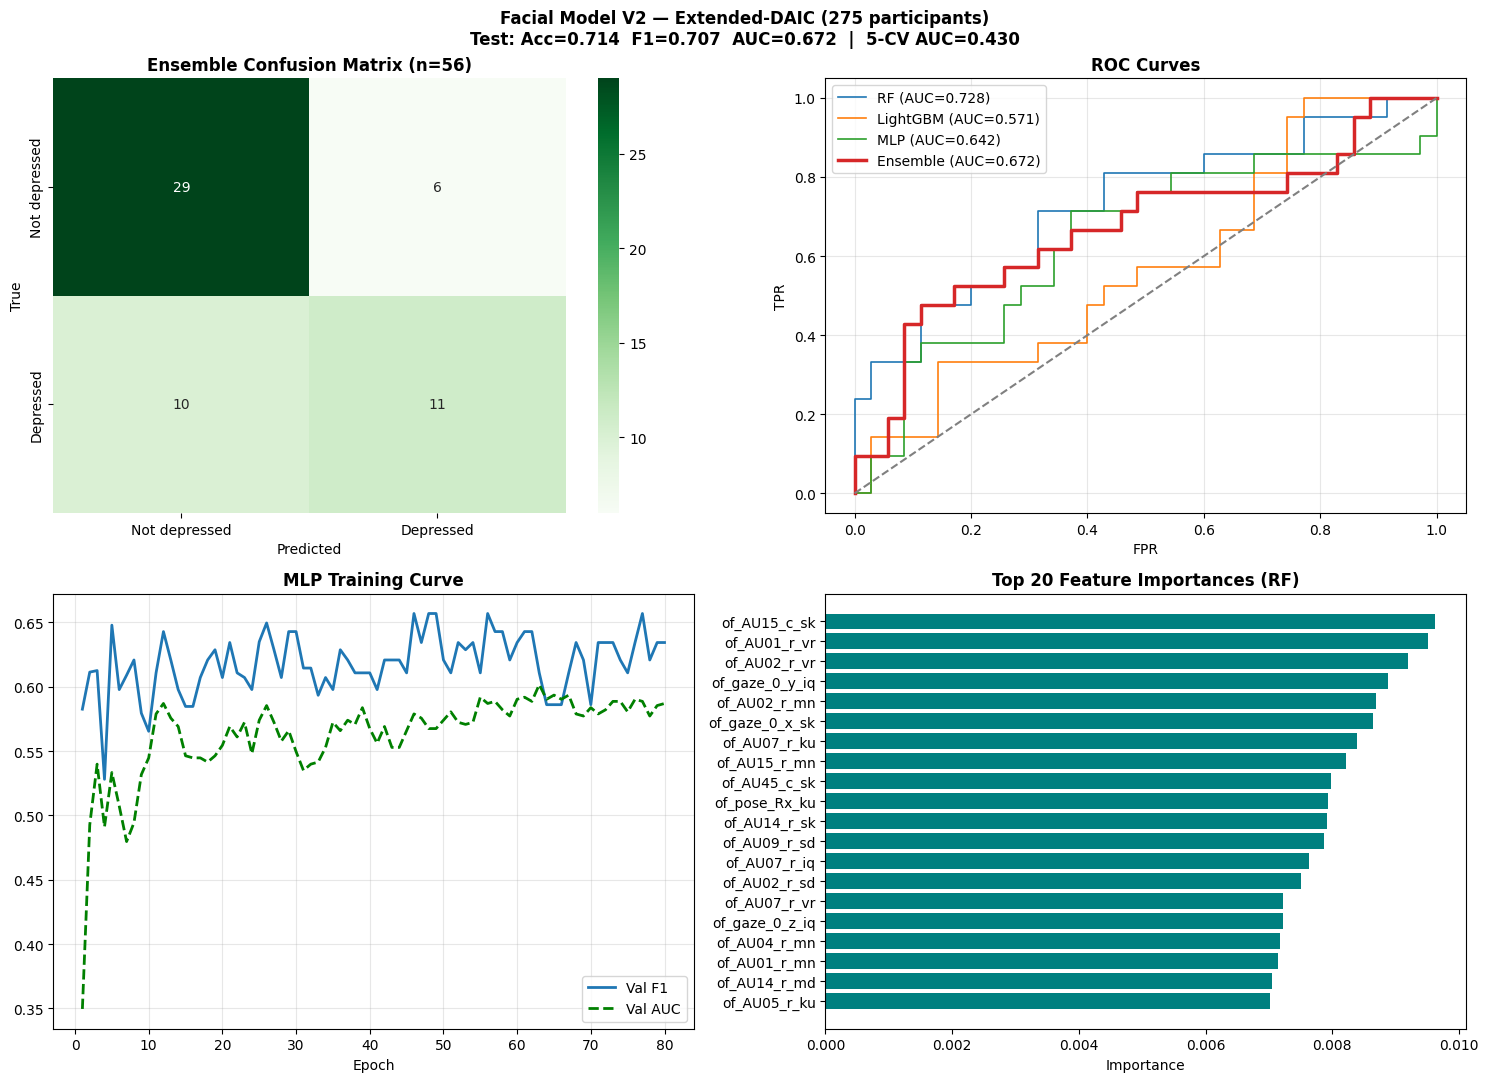

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

cm = confusion_matrix(y_te, ens_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0,0])
axes[0,0].set_title(f'Ensemble Confusion Matrix (n={len(y_te)})', fontweight='bold')
axes[0,0].set_xlabel('Predicted'); axes[0,0].set_ylabel('True')

for name, prob in [('RF',rf_te_prob),('LightGBM',lgbm_te_prob),
                   ('MLP',mlp_prob),('Ensemble',ens_prob)]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    auc = roc_auc_score(y_te, prob)
    lw  = 2.5 if name=='Ensemble' else 1.2
    axes[0,1].plot(fpr, tpr, lw=lw, label=f'{name} (AUC={auc:.3f})')
axes[0,1].plot([0,1],[0,1],'--',color='gray')
axes[0,1].set_title('ROC Curves', fontweight='bold')
axes[0,1].legend(); axes[0,1].grid(alpha=.3)
axes[0,1].set_xlabel('FPR'); axes[0,1].set_ylabel('TPR')
ep = range(1, len(hist_f1)+1)
axes[1,0].plot(ep, hist_f1,  label='Val F1',  lw=2)
axes[1,0].plot(ep, hist_auc, label='Val AUC', lw=2, linestyle='--', color='green')
axes[1,0].set_title('MLP Training Curve', fontweight='bold')
axes[1,0].legend(); axes[1,0].grid(alpha=.3)
axes[1,0].set_xlabel('Epoch')
rf_interp = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=SEED, n_jobs=-1)
rf_interp.fit(X_tr_raw, y_tr)
fi   = rf_interp.feature_importances_
top  = np.argsort(fi)[::-1][:20]
axes[1,1].barh([sel_cols[i][:35] for i in top[::-1]], fi[top[::-1]], color='teal')
axes[1,1].set_title('Top 20 Feature Importances (RF)', fontweight='bold')
axes[1,1].set_xlabel('Importance')

plt.suptitle(
    f'Facial Model V2 — Extended-DAIC ({len(facial_df)} participants)\n'
    f'Test: Acc={metrics_all[best_name]["accuracy"]:.3f}  '
    f'F1={metrics_all[best_name]["f1"]:.3f}  '
    f'AUC={metrics_all[best_name]["roc_auc"]:.3f}  |  '
    f'5-CV AUC={cv_auc:.3f}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(os.path.join(OUT,'facial_results_v2.png'), dpi=150)
plt.show()

## Step 14 — Save Models + Extract Rich 128-dim Embeddings

In [ ]:
joblib.dump(rf,     os.path.join(OUT,'facial_rf.pkl'))
joblib.dump(lgbm,   os.path.join(OUT,'facial_lgbm.pkl'))
joblib.dump(scaler, os.path.join(OUT,'facial_scaler.pkl'))
joblib.dump(pca,    os.path.join(OUT,'facial_pca.pkl'))
joblib.dump(vt,     os.path.join(OUT,'facial_vt.pkl'))
with open(os.path.join(OUT,'facial_feat_cols.json'),'w') as f: json.dump(sel_cols, f)
with open(os.path.join(OUT,'facial_thresholds.json'),'w') as f:
    json.dump({'rf': rf_thr, 'lgbm': lgbm_thr, 'mlp': mlp_thr,
               'ensemble': best_ens_thr, 'weights': list(best_w)}, f, indent=2)
print('Models + thresholds saved')

X_raw_initial = combined[all_feat_cols].values.astype(np.float32)

X_all_v   = vt.transform(X_raw_initial)
X_all_s   = scaler.transform(X_all_v)
X_all_pca2= pca.transform(X_all_s)

mlp.eval()
all_tensor = torch.tensor(X_all_pca2, dtype=torch.float32)
mlp_emb_list, mlp_prob_list_all = [], []
with torch.no_grad():
    for i in range(0, len(all_tensor), 32):
        batch = all_tensor[i:i+32].to(DEVICE)
        mlp_emb_list.append(mlp.embed(batch).cpu().numpy())
        mlp_prob_list_all.append(torch.softmax(mlp(batch),-1).cpu().numpy())

mlp_emb_all  = np.vstack(mlp_emb_list)
mlp_prob_all = np.vstack(mlp_prob_list_all)
rf_all   = rf.predict_proba(X_all_pca2)
lgbm_all = lgbm.predict_proba(X_all_pca2)
ens_all = (
    W_RF  * rf_all[:,1]
    + W_LGB * lgbm_all[:,1]
    + W_MLP * mlp_prob_all[:,1]
).reshape(-1,1)

facial_emb = np.hstack([
    mlp_emb_all,          
    rf_all[:,1:2],        
    lgbm_all[:,1:2],     
    mlp_prob_all[:,1:2], 
    ens_all,            
])

np.savez(os.path.join(OUT,'facial_embeddings.npz'), embeddings=facial_emb, ids=pids)
print(f'Facial embeddings: {facial_emb.shape}  (128-dim MLP + 4 probs)')

print('\n📦 Output files:')
for fn in sorted(os.listdir(OUT)):
    print(f'  {fn:<45} {os.path.getsize(os.path.join(OUT,fn))/1e6:.2f} MB')


Models + thresholds saved
Facial embeddings: (275, 132)  (128-dim MLP + 4 probs)

📦 Output files:
  facial_embeddings.npz                         0.29 MB
  facial_feat_cols.json                         0.01 MB
  facial_features_combined.csv                  1.56 MB
  facial_lgbm.pkl                               0.07 MB
  facial_metrics.json                           0.00 MB
  facial_mlp.pt                                 0.83 MB
  facial_pca.pkl                                0.11 MB
  facial_results_v2.png                         0.28 MB
  facial_rf.pkl                                 2.62 MB
  facial_scaler.pkl                             0.01 MB
  facial_thresholds.json                        0.00 MB
  facial_vt.pkl                                 0.00 MB


## Summary

In [28]:
print('\n' + '='*65)
print('  FACIAL MODEL V2 — FINAL SUMMARY')
print('='*65)
print(f'  Dataset     : DAIC-WOZ + Extended-DAIC ({len(facial_df)} participants)')
print(f'  Features    : {X_raw.shape[1]} (after variance filter) → PCA={pca.n_components_}')
print(f'  Best model  : {best_name}')
bm = metrics_all[best_name]
print(f'  Accuracy    : {bm["accuracy"]:.4f}')
print(f'  F1-weighted : {bm["f1"]:.4f}')
print(f'  F1-macro    : {bm["f1_macro"]:.4f}')
print(f'  F1-positive : {bm["f1_pos"]:.4f}')
print(f'  ROC-AUC     : {bm["roc_auc"]:.4f}')
print(f'\n  5-Fold CV (LightGBM on all participants):')
print(f'  Accuracy={cv_acc:.4f}  F1-macro={cv_mf1:.4f}  AUC={cv_auc:.4f}')
print(f'\n  Embedding dim: {facial_emb.shape[1]} (for fusion model)')
print('='*65)


  FACIAL MODEL V2 — FINAL SUMMARY
  Dataset     : DAIC-WOZ + Extended-DAIC (275 participants)
  Features    : 357 (after variance filter) → PCA=77
  Best model  : Ensemble
  Accuracy    : 0.7143
  F1-weighted : 0.7070
  F1-macro    : 0.6814
  F1-positive : 0.5789
  ROC-AUC     : 0.6721

  5-Fold CV (LightGBM on all participants):
  Accuracy=0.6836  F1-macro=0.4060  AUC=0.4302

  Embedding dim: 132 (for fusion model)
